--- Verifying Analytical Cosmography ---
At z = 0.5:
  dA''' | Analytical: 6727.814155773727
  dA''' | Numerical:  7048.583938740192
  Error: 320.76978296646485


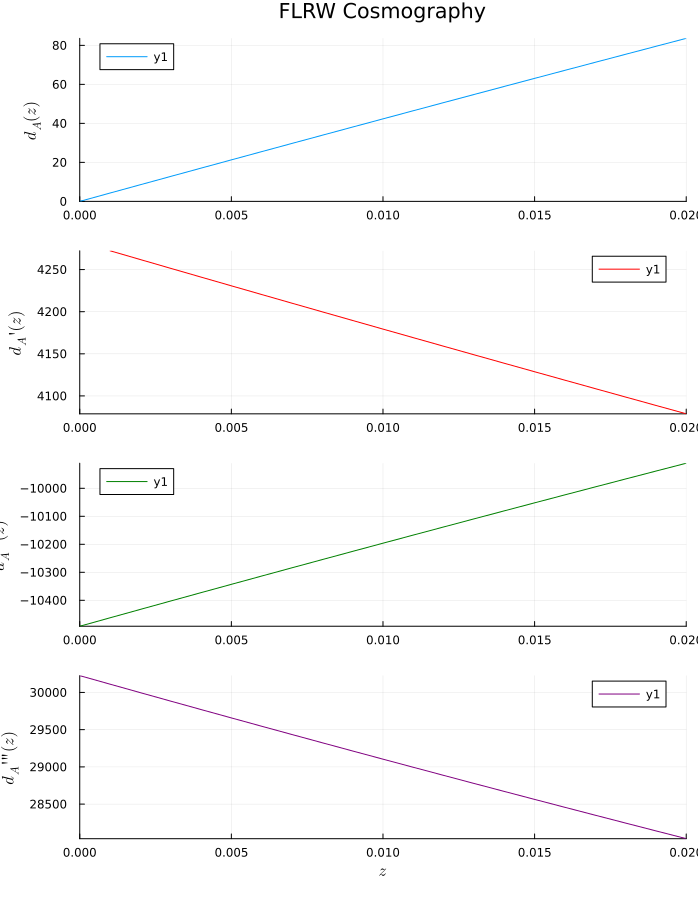

In [13]:
using ForwardDiff, QuadGK, Plots, LaTeXStrings

#=============================================================================#
# 1. Physical Constants
#=============================================================================#
const H_0 = 71.58781594e-3   
const c   = 306.5926758        
const Ω_Λ = 0.7
const Ω_m = 0.3

#=============================================================================#
# 2. The FLRW Cosmography Logic
#=============================================================================#

H_FLRW(z) = H_0 * sqrt(Ω_m * (1+z)^3 + Ω_Λ)
dHdz_FLRW(z) = (H_0^2 * 1.5 * Ω_m * (1+z)^2) / H_FLRW(z)
d2Hdz2_FLRW(z) = (3.0 * H_0^2 * Ω_m * (1+z)) / H_FLRW(z) - (dHdz_FLRW(z)^2 / H_FLRW(z))

# Distance dA(z)
function dA_FLRW(z::Real)
    z_val = Float64(z) 
    if z_val < 1e-12 return 0.0 end
    integrand(zp) = c / H_FLRW(zp)
    chi, _ = quadgk(integrand, 0.0, z_val)
    return chi / (1.0 + z_val)
end

# Analytical First Derivative
function ddA_dz_ana(z)
    da = dA_FLRW(z)
    return (1/(1+z)) * (c/H_FLRW(z) - da)
end

# Analytical Second Derivative
function d2dA_dz2_ana(z)
    h   = H_FLRW(z)
    hp  = dHdz_FLRW(z)
    da  = dA_FLRW(z)
    dap = ddA_dz_ana(z)
    
    term1 = - (1/(1+z)^2) * (c/h - da)
    term2 = (1/(1+z)) * (-c*hp/h^2 - dap)
    return term1 + term2
end

# Analytical Third Derivative
function d3dA_dz3_ana(z)
    h    = H_FLRW(z)
    hp   = dHdz_FLRW(z)
    hpp  = d2Hdz2_FLRW(z)
    da   = dA_FLRW(z)
    dap  = ddA_dz_ana(z)
    dapp = d2dA_dz2_ana(z)
    
    # Derivative of the first bracket term: -1/(1+z)^2 * (c/h - da)
    d_term1 = 2/(1+z)^3 * (c/h - da) - 1/(1+z)^2 * (-c*hp/h^2 - dap)
    
    # Derivative of the second bracket term: 1/(1+z) * (-c*hp/h^2 - dap)
    # let f = -c*hp/h^2 - dap
    f = -c*hp/h^2 - dap
    df = -c*(hpp/h^2 - 2*hp^2/h^3) - dapp
    d_term2 = -1/(1+z)^2 * f + 1/(1+z) * df
    
    return d_term1 + d_term2
end

#=============================================================================#
# 3. Robust Verification
#=============================================================================#

function run_cosmo_verification()
    println("--- Verifying Analytical Cosmography ---")
    
    z_test = 0.5
    h = 1e-5
    
    # Central difference for 3rd derivative
    f_ppp = (dA_FLRW(z_test + 2h) - 2*dA_FLRW(z_test + h) + 2*dA_FLRW(z_test - h) - dA_FLRW(z_test - 2h)) / (2 * h^3)
    
    ana_ppp = d3dA_dz3_ana(z_test)
    
    println("At z = $z_test:")
    println("  dA''' | Analytical: $ana_ppp")
    println("  dA''' | Numerical:  $f_ppp")
    println("  Error: $(abs(ana_ppp - f_ppp))")

    # Plotting
    zs = 0.0:0.001:0.02
    p1 = plot(zs, dA_FLRW.(zs), ylabel=L"d_A(z)", title="FLRW Cosmography")
    p2 = plot(zs, ddA_dz_ana.(zs), ylabel=L"d_A'(z)", color=:red)
    p3 = plot(zs, d2dA_dz2_ana.(zs), ylabel=L"d_A''(z)", color=:green)
    p4 = plot(zs, d3dA_dz3_ana.(zs), ylabel=L"d_A'''(z)", xlabel=L"z", color=:purple)
    
    # Set limits for small z as requested
    xlims!(p1, 0, 0.02); ylims!(p1, dA_FLRW(0.0), dA_FLRW(0.02))
    xlims!(p2, 0, 0.02); ylims!(p2, ddA_dz_ana(0.02), ddA_dz_ana(0.001))
    xlims!(p3, 0, 0.02); ylims!(p3, d2dA_dz2_ana(0.0), d2dA_dz2_ana(0.02))
    xlims!(p4, 0, 0.02); ylims!(p4, d3dA_dz3_ana(0.02), d3dA_dz3_ana(0.00))

    display(plot(p1, p2, p3, p4, layout=(4,1), size=(700,900)))
end

run_cosmo_verification()

In [7]:
# =============================================================================
# Imports
# =============================================================================
using NPZ
using Plots
using Plots.Measures # Required for margin adjustments
using PGFPlotsX      # Native PGF/LaTeX rendering
using LaTeXStrings
using PlotUtils

# =============================================================================
# Configuration
# =============================================================================
const DATA_DIR = "data/pixels_diov"
const BASE_PLOT_DIR = "plots_diov"

isdir(BASE_PLOT_DIR) || mkdir(BASE_PLOT_DIR)

# PGFPlotsX & Plots.jl Setup 
pgfplotsx() 
push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")

Plots.default(
    fontfamily = "Computer Modern",
    titlefont  = font(11, "Computer Modern"), 
    guidefont  = font(11, "Computer Modern"), 
    tickfont   = font(10, "Computer Modern"), 
    legendfont = font(10, "Computer Modern"), 
    size       = (320, 375),  
    linewidth  = 1,         
    legend     = :topleft     
)

# Color Palette Setup
tol_colors = PlotUtils.palette(:tol_bright)
line_colors = [tol_colors[1], tol_colors[2], tol_colors[3], tol_colors[5], tol_colors[4]]

# =============================================================================
# Utility Functions
# =============================================================================
function dA_exp(z, z_range, dA, dA_z, dA_zz, dA_zzz)
    z_eval = round(Int, z * 1e5 + 1)
    dz = z_range .- z
    return @. dA[z_eval] + dA_z[z_eval] * dz + 0.5 * dA_zz[z_eval] * dz^2 + (1/6) * dA_zzz[z_eval] * dz^3
end

function pgf_safe(y; limit=1000.0)
    return clamp.(y, -limit, limit)
end

# =============================================================================
# Minimal Data Loading 
# =============================================================================
println("Loading data for target pixel...")
# Instead of loading all NPIX maps into memory, we just load pixel 1000 directly.
# (If you don't have pixel 1000 saved independently, change this to pixel 1)
data         = npzread(joinpath(DATA_DIR, "dA_pixel_1000.npz"))
z_range      = data["z_range"]
dA_exact     = data["dA"]
dA_z_exact   = data["dA_z"]
dA_zz_exact  = data["dA_zz"]
dA_zzz_exact = data["dA_zzz"]

# =============================================================================
# Plot Generation
# =============================================================================
println("Generating combined plot...")

# --- Top Plot ---
p1 = Plots.plot(z_range, pgf_safe(dA_exact), label="Exact", color=line_colors[1], legend=:bottomright)
Plots.plot!(p1, z_range, pgf_safe(dA_exp(0.000, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact)), label=L"z_*=0.000", ls=:dash, color=line_colors[2])
Plots.plot!(p1, z_range, pgf_safe(dA_exp(0.002, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact)), label=L"z_*=0.002", ls=:dot, color=line_colors[3])
Plots.plot!(p1, z_range, pgf_safe(dA_exp(0.004, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact)), label=L"z_*=0.004", ls=:dashdot, color=line_colors[4])
Plots.plot!(p1, z_range, pgf_safe(dA_exp(0.006, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact)), label=L"z_*=0.006", ls=:dashdotdot, color=line_colors[5])
Plots.ylabel!(p1, L"d_A")
Plots.title!(p1, L"d_A \text{ exact vs expansion (fiducial ray, LTB2)}")
Plots.xlims!(p1, 0, 0.008)
Plots.ylims!(p1, 0, 34)

# Remove x-ticks and reduce bottom margin to pull the plots together
Plots.plot!(p1, xlabel="", xticks=:none, bottom_margin=-5mm)


# --- Bottom Plot ---
dA_exact_safe = copy(dA_exact)
dA_exact_safe[dA_exact_safe .== 0] .= 1e-10 

p2 = Plots.plot(z_range, pgf_safe(dA_exact ./ dA_exact_safe, limit=100.0), label="Exact", color=line_colors[1], legend=:none)
Plots.plot!(p2, z_range, pgf_safe(dA_exp(0.000, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact) ./ dA_exact_safe, limit=100.0), label=L"z_*=0.000", ls=:dash, color=line_colors[2])
Plots.plot!(p2, z_range, pgf_safe(dA_exp(0.002, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact) ./ dA_exact_safe, limit=100.0), label=L"z_*=0.002", ls=:dot, color=line_colors[3])
Plots.plot!(p2, z_range, pgf_safe(dA_exp(0.004, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact) ./ dA_exact_safe, limit=100.0), label=L"z_*=0.004", ls=:dashdot, color=line_colors[4])
Plots.plot!(p2, z_range, pgf_safe(dA_exp(0.006, z_range, dA_exact, dA_z_exact, dA_zz_exact, dA_zzz_exact) ./ dA_exact_safe, limit=100.0), label=L"z_*=0.006", ls=:dashdotdot, color=line_colors[5])
Plots.xlabel!(p2, L"z")
Plots.ylabel!(p2, L"d_A/d_{A,\mathrm{exact}}")
Plots.xlims!(p2, 0, 0.008)
Plots.ylims!(p2, -1, 3)

# Reduce top margin to meet the top plot
Plots.plot!(p2, top_margin=-5mm)


# --- Combine and Save ---
p_combined = Plots.plot(p1, p2, 
    layout = grid(2, 1, heights=[2/3, 1/3]),
    link = :x 
)

Plots.savefig(p_combined, joinpath(BASE_PLOT_DIR, "fiducial_ray_combined.pdf"))
Plots.savefig(p_combined, joinpath(BASE_PLOT_DIR, "fiducial_ray_combined.tex"))

println("Done! Plot saved to $(BASE_PLOT_DIR)/fiducial_ray_combined.pdf")

Loading data for target pixel...
Generating combined plot...
Done! Plot saved to plots_diov/fiducial_ray_combined.pdf


In [7]:
using NPZ
const DATA_DIR = "data/pixels_void_offcentre_20"
data0   = npzread(joinpath(DATA_DIR, "dA_pixel_1.npz"))
z_range = data0["z_range"]
nz      = length(z_range)

for gap in [1, 2, 4]
    for (i, z) in enumerate(z_range)
        bin = floor(Int, (z + (0.008/(20*gap))/2) / (0.008/(20*gap)))
        iz0 = 1 + gap * 100 * bin
        iz0 = min(iz0, nz)
        print(bin, " ")
    end
end

0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 

Pixel 1000: θ = 0.9350850413935945, φ = 0.7608544707912779


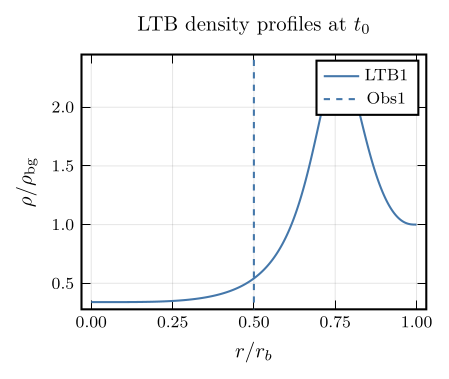

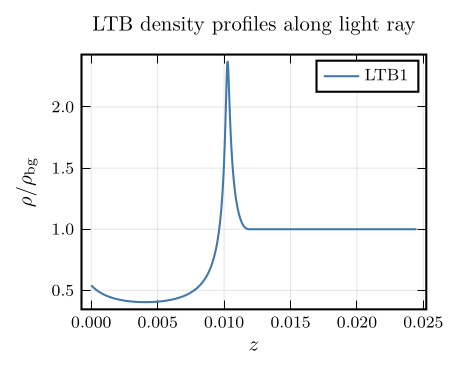

In [8]:
#import Pkg; Pkg.add.(["DifferentialEquations", "Plots", "LaTeXStrings", "PGFPlotsX", "Interpolations", "QuadGK", "ForwardDiff", "NPZ", "Healpix"])
using DifferentialEquations
using Plots
using LaTeXStrings
using PGFPlotsX
using Interpolations
using QuadGK
using ForwardDiff
using NPZ
using Healpix
using Base.Threads
# Plot as .tex (Tikz) files
#pgfplotsx()
#push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")
gr()
default(linewidth=1, framestyle=:box, grid=true, label=nothing, legend=:topright)

#=============================================================================#
# Defining basic constants and cosmological parameters
#=============================================================================#

# Physical constants and parameters
# Fundamental constants
const H_0 = 71.58781594e-3   # Hubble constant [1/Gyr]
const c = 306.5926758        # Speed of light [Mpc/Gyr]
const G_N = 4.498234911e-15  # G in Mpc^3/(M_sun*Gyr^2)

# Cosmological parameters
const Ω_Λ = 0.7
const Ω_m = 0.3

# LTB parameters
const r_b = 40.0
const k_max = 5.4e-8
const n = 4
const m = 4

# Initial conditions
const a_i = 1/1200
const H_i = H_0 * sqrt(Ω_m * a_i^(-3) + Ω_Λ)
const Lambda = 3 * Ω_Λ * H_0^2
const rho_bg = 3 * Ω_m * H_0^2 / (8 * pi * G_N) / a_i^3

# Numerical solution of LTB dynamics
const r_grid = range(1e-6, r_b, length=1_000)
const N = length(r_grid)

# Energy functions for cosmography
const Eo = -c
const Ec = Eo/c^2

# Initial conditions for ray tracing
const xr0 = 20.0# 20 for void, 10 for diov#10.0 #0.1
const xθ0 = pi/2
const xϕ0 = 0

const kt0 = -1/c

const r_σ = 7.0
const δ_0 = 1e-3  # Your new "small" amplitude parameter
const M_bg_coeff = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2
const k_0 = 5/3 * (a_i * H_i / c)^2

# Healpix
Nside = 64
npix  = nside2npix(Nside)

map = HealpixMap{Float64, NestedOrder}(Nside)

theta_hp, phi_hp = pix2ang(map, 1000)
println("Pixel 1000: θ = $theta_hp, φ = $phi_hp")

#=============================================================================#
# Setting up LTB model
#=============================================================================#

# LTB functions
K(r) = ifelse(r > r_b, 0.0, -r^2 * k_max * ((r/r_b)^n - 1)^m)
K_r(r) = ifelse(r > r_b, 0.0, -2*r*k_max*((r/r_b)^n - 1)^m - r*k_max*n*m*((r/r_b)^n-1)^(m-1)*(r/r_b)^n)
K_rr(r) = ifelse(r > r_b, 0.0, -2*k_max*((r/r_b)^n - 1)^m - k_max*n*m*(3+n)*((r/r_b)^n - 1)^(m-1)*(r/r_b)^n - k_max*n^2*m*(m-1)*((r/r_b)^n - 1)^(m-2)*(r/r_b)^(2n))

M(r) = 4/3 * pi * G_N * r^3 * a_i^3 * rho_bg / c^2 * (1 + 3/5 * K(r) * c^2 / (a_i*H_i*r)^2)
M_r(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (3*r^2 + 3/5 * c^2/(a_i*H_i)^2 * (K(r) + r*K_r(r)))
M_rr(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (6*r + 3/5 * c^2/(a_i*H_i)^2 * (2*K_r(r) + r*K_rr(r)))
#=
# DIOV
# The Gaussian density perturbation
δ(r) = δ_0 * exp(-r^2 / (2 * r_σ^2))

# M(r) and its analytical derivatives
M(r)    = M_bg_coeff * r^3 * (1 + δ(r))
M_r(r)  = M_bg_coeff * r^2 * (3 + δ(r) * (3 - (r/r_σ)^2))
M_rr(r) = M_bg_coeff * r * (6 + δ(r) * (6 - 7*(r/r_σ)^2 + (r/r_σ)^4))

# K(r) and its analytical derivatives
K(r)    = k_0 * r^2 * δ(r)
K_r(r)  = k_0 * r * δ(r) * (2 - (r/r_σ)^2)
K_rr(r) = k_0 * δ(r) * (2 - 5*(r/r_σ)^2 + (r/r_σ)^4)
=#
# LCDM background
t_of_a(a) = (2/3) * (1/H_0) / sqrt(Ω_Λ) * asinh(sqrt(Ω_Λ/Ω_m) * a^(3/2))
a(t) = (Ω_m/Ω_Λ)^(1/3) * cbrt(sinh((3/2) * sqrt(Ω_Λ) * H_0 * t))^2
a_t(t) = H_0 * sqrt(Ω_m/a(t) + Ω_Λ * a(t)^2)
H_FLRW(z) = H_0 * sqrt(Ω_m * (1+z)^3 + Ω_Λ)

# Numerical solution of LTB dynamics
t_0 = t_of_a(1.0)
t_i = t_of_a(a_i)
tspan = (t_i, t_0)

# Initial conditions
A_i(r) = a_i * r
A_r_i(r) = a_i
A_rr_i(r) = 0.0
u0 = [A_i.(r_grid); A_r_i.(r_grid); A_rr_i.(r_grid)]

# Parameters for ODEs
p = (
    -K.(r_grid) * c^2,               # p[1]
    2*M.(r_grid) * c^2,           # p[2]
    fill(Lambda/3, length(r_grid)),   # p[3]
    2*M_r.(r_grid) * c^2,         # p[4]
    2*M.(r_grid) * c^2,           # p[5]
    -K_r.(r_grid) * c^2,             # p[6]
    fill(2*Lambda/3, length(r_grid)), # p[7]
    -K_rr.(r_grid) * c^2,            # p[8]
    2*M_rr.(r_grid) * c^2,        # p[9]
    -4*M_r.(r_grid) * c^2,        # p[10]
    4*M.(r_grid) * c^2            # p[11]
)

# Defining the system of ODEs for A, A_r, and A_rr
function LTB_eq!(du, u, p, t)
    N = length(u) ÷ 3
    A   = @view u[1:N]
    Ar  = @view u[N+1:2N]
    Arr = @view u[2N+1:end]
    dA   = @view du[1:N]
    dAr  = @view du[N+1:2N]
    dArr = @view du[2N+1:end]

    @. dA = sqrt(p[1] + p[2]/A + p[3]*A^2)
    @. dAr = (p[4]/A - (p[5]*Ar)/(A^2) + p[6] + p[7]*A*Ar) / (2 * dA)
    @. dArr = ((p[8] + p[9]/A + (p[10]*Ar)/(A^2) + (p[11]*Ar^2)/(A^3) - (p[5]*Arr)/(A^2) + p[7]*Ar^2 + p[7]*A*Arr) - 2*dAr^2) / (2 * dA)
end

    
prob_LTB = ODEProblem(LTB_eq!, u0, tspan, p)
sol_LTB = solve(prob_LTB, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Interpolate solution for A, A_r, A_rr and their time derivatives
# GEMINI INSERT START
# 1. Local cubic curve math
@inline function local_cubic(y1, y2, y3, y4, w)
    return y2 + 0.5 * w * (y3 - y1 + w * (2.0*y1 - 5.0*y2 + 4.0*y3 - y4 + w * (3.0*(y2 - y3) + y4 - y1)))
end

# 2. Dynamic, extrapolation-safe evaluator
function fast_eval(sol, t, r, offset, t_deriv=false)
    # Use your dynamically defined grid
    r_start = first(r_grid)
    r_end = last(r_grid)
    dr = step(r_grid)
    
    # Helper to grab values from the solver cleanly
    get_val(idx) = t_deriv ? sol(t, Val{1}, idxs=idx+offset) : sol(t, idxs=idx+offset)

    # Find exact position on the grid
    fi = (r - r_start) / dr + 1
    i = clamp(floor(Int, fi), 1, N-1)
    w = fi - i 
    
    # Extract 4 points. If we are right against the edge (i=1 or i=N-1), 
    # we create a "ghost point" to keep the curve perfectly smooth.
    y2 = get_val(i)
    y3 = get_val(i+1)
    y1 = i > 1 ? get_val(i-1) : 2.0*y2 - y3
    y4 = i < N-1 ? get_val(i+2) : 2.0*y3 - y2
    
    return local_cubic(y1, y2, y3, y4, w)
end

A_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0)
A_r_intp = (t,r) -> fast_eval(sol_LTB, t, r, N)
A_rr_intp = (t,r) -> fast_eval(sol_LTB, t, r, 2*N)
A_t_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0, true)
A_tr_intp = (t,r) -> fast_eval(sol_LTB, t, r, N, true)

# GEMINI INSERT END

# Direct definitions - No middle step needed
A(t, r)   = (r > r_b) ? a(t)*r   : A_intp(t, r)
A_r(t, r)  = (r > r_b) ? a(t)     : A_r_intp(t, r)
A_rr(t, r) = (r > r_b) ? 0.0      : A_rr_intp(t, r)
A_t(t, r)  = (r > r_b) ? a_t(t)*r : A_t_intp(t, r)
A_tr(t, r) = (r > r_b) ? a_t(t)   : A_tr_intp(t, r)

# LTB metric
gtt() = -c^2
grr(t, r) = A_r(t, r)^2 / (1 - K(r))
gθθ(t, r) = A(t, r)^2
gϕϕ(t, r, θ) = A(t, r)^2 * sin(θ)^2

# Calculate rho, theta and sigma of LTB
ρ(t, r) = @. (c^2 / (4*pi*G_N)) * (M_r(r) / (A(t,r)^2 * A_r(t,r)))
θ(t, r) = @. (A_tr(t,r)/A_r(t,r) + 2*A_t(t,r)/A(t,r))
σ²(t, r) = @. (1/3) * (A_tr(t,r)/A_r(t,r) - A_t(t,r)/A(t,r))^2
R(t,r, kt) = (8*pi*G_N/c^4) * ρ(t,r) * kt^2 * c^4 # R = R_\mu\nu k^\mu k^\nu


#=============================================================================#
# Ray tracing
#=============================================================================#

# Geodesic ray tracing
function geodesic_eq!(du, u, p, λ)
    @views x = u[1:4]   # Position: [t, r, θ, φ]
    @views k = u[5:8]   # Momentum: [k_t, k_r, k_θ, k_φ]
    @views D = u[9:12]  # Deviation vector
    @views D_λ = u[13:16] # Deviation velocity
    
    #if x[2] < 0.001 && k[2] < 0
    #    println("Warning: Light ray is at r=0 with negative radial momentum. Reflecting to avoid numerical issues.")
    #    k[2] = -k[2] # Reflect at r=0 to avoid numerical issues
    #end

    A_i = A(x[1], x[2])
    A_r_i = A_r(x[1], x[2])
    A_rr_i = A_rr(x[1], x[2])
    A_t_i = A_t(x[1], x[2])
    A_tr_i = A_tr(x[1], x[2])

    # Geodesic equation: dx/dλ = k
    du[1:4] .= k

    # dk/dλ = -Γ^μ_{αβ} k^α k^β
    du[5] = -(A_tr_i*A_r_i)/(c^2*(1-K(x[2]))) * k[2]^2 - (A_i*A_t_i)/c^2 * k[3]^2 - (A_i*A_t_i*sin(x[3])^2)/c^2 * k[4]^2
    du[6] = -2*(A_tr_i/A_r_i) * k[1]*k[2] - (A_rr_i/A_r_i + K_r(x[2])/(2-2*K(x[2]))) * k[2]^2 + (A_i/A_r_i)*(1-K(x[2])) * k[3]^2 + (A_i/A_r_i)*(1-K(x[2]))*sin(x[3])^2 * k[4]^2
    du[7] = -2*(A_t_i/A_i) * k[1]*k[3] - 2*(A_r_i/A_i) * k[2]*k[3] + cos(x[3])*sin(x[3]) * k[4]^2
    du[8] = -2*(A_t_i/A_i) * k[1]*k[4] - 2*(A_r_i/A_i) * k[2]*k[4] - 2*(cos(x[3])/sin(x[3])) * k[3]*k[4]

    du[9:12] .= D_λ
    du[13:16] .= -R(x[1], x[2], k[1])/2 .* D
end

# Initial conditions of light ray
x0 = [t_0, xr0, xθ0, xϕ0]

p_hat_r = sin(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) + cos(xθ0) * cos(theta_hp)
p_hat_θ = cos(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) - sin(xθ0) * cos(theta_hp)
p_hat_ϕ = sin(theta_hp) * sin(phi_hp - xϕ0)

energy_factor = kt0 * sqrt(-gtt())

kr0 = kt0 * p_hat_r * sqrt(-gtt() / grr(x0[1], x0[2]))
kθ0 = kt0 * p_hat_θ * sqrt(-gtt() / gθθ(x0[1], x0[2]))
kϕ0 = kt0 * p_hat_ϕ * sqrt(-gtt() / gϕϕ(x0[1], x0[2], x0[3]))

k0 = [kt0, kr0, kθ0, kϕ0]

k0[abs.(k0) .< 1e-15] .= 0.0 # Avoid tiny nonzero values that can cause numerical issues

D0 = [0.0, 0.0, 0.0, 0.0] # Flattening matrix D_0
D_λ0 = [1.0, 0.0, 0.0, 1.0] # Flattening matrix V_0

u0 = vcat(x0, k0, D0, D_λ0)

# Raytracing from lambda=0 to lambda=100
lspan = (0, 100)

# Tighter threshold so near-miss rays curve naturally without triggering
condition_r0(u, λ, integrator) = u[2] - 1e-15

function affect_r0!(integrator)
    # Coordinate teleportation
    integrator.u[3] = π - integrator.u[3]   # θ → π - θ
    integrator.u[4] = integrator.u[4] + π   # φ → φ + π
    
    # Momentum adjustment (Preserving the straight-line velocity)
    integrator.u[6] = -integrator.u[6]      # k_r → -k_r  (now moving outward)
    # k_θ remains unchanged! Do NOT flip u[7]
    integrator.u[8] = -integrator.u[8]      # k_φ → -k_φ
end

# Correct argument order: affect_r0! for inward falling (+ to -), nothing for outward (- to +)
cb_r0 = ContinuousCallback(condition_r0, nothing, affect_r0!)

prob_geo = ODEProblem(geodesic_eq!, u0, lspan, callback=cb_r0)
sol_geo = solve(prob_geo, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Collecting solutions
xt(λ) = sol_geo(λ)[1]
xr(λ) = sol_geo(λ)[2]
xθ(λ) = sol_geo(λ)[3]
xϕ(λ) = sol_geo(λ)[4]

kt(λ) = sol_geo(λ)[5]
kr(λ) = sol_geo(λ)[6]
kθ(λ) = sol_geo(λ)[7]
kϕ(λ) = sol_geo(λ)[8]

D(λ) = reshape(sol_geo(λ)[9:12], 2, 2)
D_λ(λ) = reshape(sol_geo(λ)[13:16], 2, 2)

#=============================================================================#
# Cosmography calculations
#=============================================================================#

z(λ) = kt(λ) / kt(0) - 1

dA(λ) = sqrt(D(λ)[1, 1]*D(λ)[2, 2] - D(λ)[1, 2]*D(λ)[2, 1])

r_comoving_FLRW(z) = first(quadgk(z_ -> 1/H_FLRW(z_), 0, z))
dA_FLRW(λ) = r_comoving_FLRW(z(λ)) * c

S(λ) = D_λ(λ) * inv(D(λ))

θ̂(λ) = (S(λ)[1, 1] .+ S(λ)[2, 2])

σ̂²(λ) = (S(λ)[1, 1]^2 + S(λ)[2, 2]^2 + S(λ)[1, 2]^2 + S(λ)[2, 1]^2 - 2 * S(λ)[1, 1] * S(λ)[2, 2] + 2 * S(λ)[1, 2] * S(λ)[2, 1])/4


σrr(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* 2/3*grr(t,r)
σθθ(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gθθ(t,r))
σϕϕ(t,r,θ) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gϕϕ(t,r,θ))


σ_proj(λ) = ((kr(λ) / (c * kt(λ)))^2 * σrr(xt(λ), xr(λ)) 
    + (kθ(λ) / (c * kt(λ)))^2 * σθθ(xt(λ), xr(λ))
    + (kϕ(λ) / (c * kt(λ)))^2 * σϕϕ(xt(λ), xr(λ), xθ(λ)))

H(λ) = θ(xt(λ), xr(λ))/3 + σ_proj(λ)

#=============================================================================#
# Derivatives of angular diameter distance
#=============================================================================#

dA_z(λ) = -θ̂(λ)/(2*(1 + z(λ))^2*Ec*H(λ))*dA(λ)

Rkk(λ) = R(xt(λ), xr(λ), kt(λ))

H_λ(λ) = ForwardDiff.derivative(H, λ)
H_λλ(λ) = ForwardDiff.derivative(H_λ, λ)
Rkk_λ(λ) = ForwardDiff.derivative(Rkk, λ)


dA_zz(λ) = (dA(λ) / (2*(1+z(λ))^4 * Ec^2 * H(λ)^2)) * (
    2*θ̂(λ)*Ec*H(λ)*(1+z(λ)) - 2*σ̂²(λ) - Rkk(λ) - (θ̂(λ)/H(λ))*H_λ(λ)
)

dA_zzz(λ) = (dA(λ) / (2*(1+z(λ))^6 * Ec^3 * H(λ)^3)) * (
    θ̂(λ)*Rkk(λ)/2 
    - 2*0 # Setting Weyl term to zero
    - 3*θ̂(λ)*σ̂²(λ) 
    + 12*Ec*H(λ)*σ̂²(λ)*(1+z(λ))
    + 6*Ec*H(λ)*Rkk(λ)*(1+z(λ))
    + 6*Ec*θ̂(λ)*(1+z(λ))*H_λ(λ)
    - 6*Ec^2*H(λ)^2*θ̂(λ)*(1+z(λ))^2
    - 6*σ̂²(λ)/H(λ)*H_λ(λ)
    - 3*Rkk(λ)/H(λ)*H_λ(λ)
    - 3*θ̂(λ)/H(λ)^2*H_λ(λ)^2
    + θ̂(λ)/H(λ)*H_λλ(λ)
    + Rkk_λ(λ)
)


z_vals = z.(sol_geo.t)
λ_of_z = linear_interpolation(z_vals, sol_geo.t, extrapolation_bc=Line())

function dA_exp(z_0)
    λ_0 = λ_of_z(z_0)
    c0_z0 = dA(λ_0)
    c1_z0 = dA_z(λ_0)
    c2_z0 = 0.5 * dA_zz(λ_0)
    c3_z0 = (1/6) * dA_zzz(λ_0)

    dA_z0(z_val) = c0_z0 + c1_z0*(z_val - z_0) + c2_z0*(z_val - z_0)^2 + c3_z0*(z_val - z_0)^3
    return dA_z0
end

#=============================================================================#
# Plotting
#=============================================================================#
λ_ = sol_geo.t[sol_geo.t .> 0.01]
z_eval = z.(λ_)

Plots.default(
    fontfamily = "Computer Modern",
    titlefont  = font(10, "Computer Modern"), # Forces title to match Makie titlesize
    guidefont  = font(10, "Computer Modern"), # Matches Makie labelsize
    tickfont   = font(8, "Computer Modern"), # Matches Makie ticklabelsize
    legendfont = font(8, "Computer Modern"), 
    size       = (300, 240),  
    linewidth  = 1,         
    legend     = :topleft     
)

pgfplotsx() 

push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")

using PlotUtils
tol_colors = PlotUtils.palette(:tol_bright)
line_colors = repeat(
    [
        tol_colors[1],
        tol_colors[2],
        tol_colors[3],
        tol_colors[5],
        tol_colors[4]
    ],
    outer = 1
)

prhor = plot(r_grid/r_b, ρ.(t_0, r_grid)/(rho_bg * a_i^3 ./ a.(t_0).^3),
    label=L"\text{LTB1}", xlabel=L"r/r_b" ,ylabel=L"\rho/\rho_\mathrm{bg}", title=L"\text{LTB density profiles at } t_0", color=line_colors[1], legend=:topright)
vline!(prhor, [xr0]/r_b, color=line_colors[1], linestyle=:dash, label="Obs1")
display(prhor)

# Density along light ray
prho = plot(z_eval, ρ(xt.(λ_), xr.(λ_)) ./ (rho_bg * a_i^3 ./ a.(xt.(λ_)).^3),
    label=L"\text{LTB1}", xlabel=L"z", ylabel=L"\rho/\rho_\mathrm{bg}", title=L"\text{LTB density profiles along light ray}", color=line_colors[1], legend=:topright)
display(prho)


Pixel 1000: θ = 0.9350850413935945, φ = 0.7608544707912779


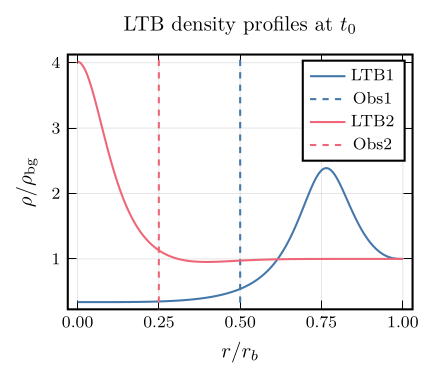

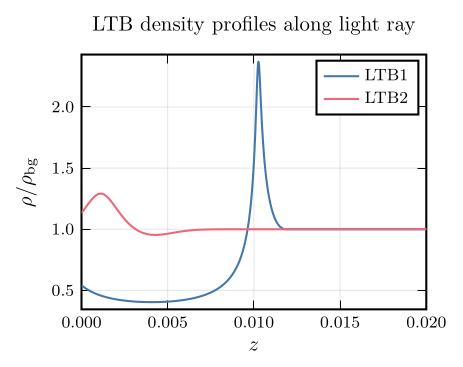

In [9]:
#import Pkg; Pkg.add.(["DifferentialEquations", "Plots", "LaTeXStrings", "PGFPlotsX", "Interpolations", "QuadGK", "ForwardDiff", "NPZ", "Healpix"])
using DifferentialEquations
using Plots
using LaTeXStrings
using PGFPlotsX
using Interpolations
using QuadGK
using ForwardDiff
using NPZ
using Healpix
using Base.Threads
# Plot as .tex (Tikz) files
#pgfplotsx()
#push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")
gr()
default(linewidth=1, framestyle=:box, grid=true, label=nothing, legend=:topright)

#=============================================================================#
# Defining basic constants and cosmological parameters
#=============================================================================#

# Physical constants and parameters
# Fundamental constants
const H_0 = 71.58781594e-3   # Hubble constant [1/Gyr]
const c = 306.5926758        # Speed of light [Mpc/Gyr]
const G_N = 4.498234911e-15  # G in Mpc^3/(M_sun*Gyr^2)

# Cosmological parameters
const Ω_Λ = 0.7
const Ω_m = 0.3

# LTB parameters
const r_b = 40.0
const k_max = 5.4e-8
const n = 4
const m = 4

# Initial conditions
const a_i = 1/1200
const H_i = H_0 * sqrt(Ω_m * a_i^(-3) + Ω_Λ)
const Lambda = 3 * Ω_Λ * H_0^2
const rho_bg = 3 * Ω_m * H_0^2 / (8 * pi * G_N) / a_i^3

# Numerical solution of LTB dynamics
const r_grid = range(1e-6, r_b, length=1_000)
const N = length(r_grid)

# Energy functions for cosmography
const Eo = -c
const Ec = Eo/c^2

# Initial conditions for ray tracing
const xr0 = 10.0# 20 for void, 10 for diov#10.0 #0.1
const xθ0 = pi/2
const xϕ0 = 0

const kt0 = -1/c

const r_σ = 7.0
const δ_0 = 1e-3  # Your new "small" amplitude parameter
const M_bg_coeff = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2
const k_0 = 5/3 * (a_i * H_i / c)^2

# Healpix
Nside = 64
npix  = nside2npix(Nside)

map = HealpixMap{Float64, NestedOrder}(Nside)

theta_hp, phi_hp = pix2ang(map, 1000)
println("Pixel 1000: θ = $theta_hp, φ = $phi_hp")

#=============================================================================#
# Setting up LTB model
#=============================================================================#
#=
# LTB functions
K(r) = ifelse(r > r_b, 0.0, -r^2 * k_max * ((r/r_b)^n - 1)^m)
K_r(r) = ifelse(r > r_b, 0.0, -2*r*k_max*((r/r_b)^n - 1)^m - r*k_max*n*m*((r/r_b)^n-1)^(m-1)*(r/r_b)^n)
K_rr(r) = ifelse(r > r_b, 0.0, -2*k_max*((r/r_b)^n - 1)^m - k_max*n*m*(3+n)*((r/r_b)^n - 1)^(m-1)*(r/r_b)^n - k_max*n^2*m*(m-1)*((r/r_b)^n - 1)^(m-2)*(r/r_b)^(2n))

M(r) = 4/3 * pi * G_N * r^3 * a_i^3 * rho_bg / c^2 * (1 + 3/5 * K(r) * c^2 / (a_i*H_i*r)^2)
M_r(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (3*r^2 + 3/5 * c^2/(a_i*H_i)^2 * (K(r) + r*K_r(r)))
M_rr(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (6*r + 3/5 * c^2/(a_i*H_i)^2 * (2*K_r(r) + r*K_rr(r)))
=#
# DIOV
# The Gaussian density perturbation
δ(r) = δ_0 * exp(-r^2 / (2 * r_σ^2))

# M(r) and its analytical derivatives
M(r)    = M_bg_coeff * r^3 * (1 + δ(r))
M_r(r)  = M_bg_coeff * r^2 * (3 + δ(r) * (3 - (r/r_σ)^2))
M_rr(r) = M_bg_coeff * r * (6 + δ(r) * (6 - 7*(r/r_σ)^2 + (r/r_σ)^4))

# K(r) and its analytical derivatives
K(r)    = k_0 * r^2 * δ(r)
K_r(r)  = k_0 * r * δ(r) * (2 - (r/r_σ)^2)
K_rr(r) = k_0 * δ(r) * (2 - 5*(r/r_σ)^2 + (r/r_σ)^4)

# LCDM background
t_of_a(a) = (2/3) * (1/H_0) / sqrt(Ω_Λ) * asinh(sqrt(Ω_Λ/Ω_m) * a^(3/2))
a(t) = (Ω_m/Ω_Λ)^(1/3) * cbrt(sinh((3/2) * sqrt(Ω_Λ) * H_0 * t))^2
a_t(t) = H_0 * sqrt(Ω_m/a(t) + Ω_Λ * a(t)^2)
H_FLRW(z) = H_0 * sqrt(Ω_m * (1+z)^3 + Ω_Λ)

# Numerical solution of LTB dynamics
t_0 = t_of_a(1.0)
t_i = t_of_a(a_i)
tspan = (t_i, t_0)

# Initial conditions
A_i(r) = a_i * r
A_r_i(r) = a_i
A_rr_i(r) = 0.0
u0 = [A_i.(r_grid); A_r_i.(r_grid); A_rr_i.(r_grid)]

# Parameters for ODEs
p = (
    -K.(r_grid) * c^2,               # p[1]
    2*M.(r_grid) * c^2,           # p[2]
    fill(Lambda/3, length(r_grid)),   # p[3]
    2*M_r.(r_grid) * c^2,         # p[4]
    2*M.(r_grid) * c^2,           # p[5]
    -K_r.(r_grid) * c^2,             # p[6]
    fill(2*Lambda/3, length(r_grid)), # p[7]
    -K_rr.(r_grid) * c^2,            # p[8]
    2*M_rr.(r_grid) * c^2,        # p[9]
    -4*M_r.(r_grid) * c^2,        # p[10]
    4*M.(r_grid) * c^2            # p[11]
)

# Defining the system of ODEs for A, A_r, and A_rr
function LTB_eq!(du, u, p, t)
    N = length(u) ÷ 3
    A   = @view u[1:N]
    Ar  = @view u[N+1:2N]
    Arr = @view u[2N+1:end]
    dA   = @view du[1:N]
    dAr  = @view du[N+1:2N]
    dArr = @view du[2N+1:end]

    @. dA = sqrt(p[1] + p[2]/A + p[3]*A^2)
    @. dAr = (p[4]/A - (p[5]*Ar)/(A^2) + p[6] + p[7]*A*Ar) / (2 * dA)
    @. dArr = ((p[8] + p[9]/A + (p[10]*Ar)/(A^2) + (p[11]*Ar^2)/(A^3) - (p[5]*Arr)/(A^2) + p[7]*Ar^2 + p[7]*A*Arr) - 2*dAr^2) / (2 * dA)
end

    
prob_LTB = ODEProblem(LTB_eq!, u0, tspan, p)
sol_LTB = solve(prob_LTB, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Interpolate solution for A, A_r, A_rr and their time derivatives
# GEMINI INSERT START
# 1. Local cubic curve math
@inline function local_cubic(y1, y2, y3, y4, w)
    return y2 + 0.5 * w * (y3 - y1 + w * (2.0*y1 - 5.0*y2 + 4.0*y3 - y4 + w * (3.0*(y2 - y3) + y4 - y1)))
end

# 2. Dynamic, extrapolation-safe evaluator
function fast_eval(sol, t, r, offset, t_deriv=false)
    # Use your dynamically defined grid
    r_start = first(r_grid)
    r_end = last(r_grid)
    dr = step(r_grid)
    
    # Helper to grab values from the solver cleanly
    get_val(idx) = t_deriv ? sol(t, Val{1}, idxs=idx+offset) : sol(t, idxs=idx+offset)

    # Find exact position on the grid
    fi = (r - r_start) / dr + 1
    i = clamp(floor(Int, fi), 1, N-1)
    w = fi - i 
    
    # Extract 4 points. If we are right against the edge (i=1 or i=N-1), 
    # we create a "ghost point" to keep the curve perfectly smooth.
    y2 = get_val(i)
    y3 = get_val(i+1)
    y1 = i > 1 ? get_val(i-1) : 2.0*y2 - y3
    y4 = i < N-1 ? get_val(i+2) : 2.0*y3 - y2
    
    return local_cubic(y1, y2, y3, y4, w)
end

A_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0)
A_r_intp = (t,r) -> fast_eval(sol_LTB, t, r, N)
A_rr_intp = (t,r) -> fast_eval(sol_LTB, t, r, 2*N)
A_t_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0, true)
A_tr_intp = (t,r) -> fast_eval(sol_LTB, t, r, N, true)

# GEMINI INSERT END

# Direct definitions - No middle step needed
A(t, r)   = (r > r_b) ? a(t)*r   : A_intp(t, r)
A_r(t, r)  = (r > r_b) ? a(t)     : A_r_intp(t, r)
A_rr(t, r) = (r > r_b) ? 0.0      : A_rr_intp(t, r)
A_t(t, r)  = (r > r_b) ? a_t(t)*r : A_t_intp(t, r)
A_tr(t, r) = (r > r_b) ? a_t(t)   : A_tr_intp(t, r)

# LTB metric
gtt() = -c^2
grr(t, r) = A_r(t, r)^2 / (1 - K(r))
gθθ(t, r) = A(t, r)^2
gϕϕ(t, r, θ) = A(t, r)^2 * sin(θ)^2

# Calculate rho, theta and sigma of LTB
ρ(t, r) = @. (c^2 / (4*pi*G_N)) * (M_r(r) / (A(t,r)^2 * A_r(t,r)))
θ(t, r) = @. (A_tr(t,r)/A_r(t,r) + 2*A_t(t,r)/A(t,r))
σ²(t, r) = @. (1/3) * (A_tr(t,r)/A_r(t,r) - A_t(t,r)/A(t,r))^2
R(t,r, kt) = (8*pi*G_N/c^4) * ρ(t,r) * kt^2 * c^4 # R = R_\mu\nu k^\mu k^\nu

#=============================================================================#
# Ray tracing
#=============================================================================#

# Geodesic ray tracing
function geodesic_eq!(du, u, p, λ)
    @views x = u[1:4]   # Position: [t, r, θ, φ]
    @views k = u[5:8]   # Momentum: [k_t, k_r, k_θ, k_φ]
    @views D = u[9:12]  # Deviation vector
    @views D_λ = u[13:16] # Deviation velocity
    
    #if x[2] < 0.001 && k[2] < 0
    #    println("Warning: Light ray is at r=0 with negative radial momentum. Reflecting to avoid numerical issues.")
    #    k[2] = -k[2] # Reflect at r=0 to avoid numerical issues
    #end

    A_i = A(x[1], x[2])
    A_r_i = A_r(x[1], x[2])
    A_rr_i = A_rr(x[1], x[2])
    A_t_i = A_t(x[1], x[2])
    A_tr_i = A_tr(x[1], x[2])

    # Geodesic equation: dx/dλ = k
    du[1:4] .= k

    # dk/dλ = -Γ^μ_{αβ} k^α k^β
    du[5] = -(A_tr_i*A_r_i)/(c^2*(1-K(x[2]))) * k[2]^2 - (A_i*A_t_i)/c^2 * k[3]^2 - (A_i*A_t_i*sin(x[3])^2)/c^2 * k[4]^2
    du[6] = -2*(A_tr_i/A_r_i) * k[1]*k[2] - (A_rr_i/A_r_i + K_r(x[2])/(2-2*K(x[2]))) * k[2]^2 + (A_i/A_r_i)*(1-K(x[2])) * k[3]^2 + (A_i/A_r_i)*(1-K(x[2]))*sin(x[3])^2 * k[4]^2
    du[7] = -2*(A_t_i/A_i) * k[1]*k[3] - 2*(A_r_i/A_i) * k[2]*k[3] + cos(x[3])*sin(x[3]) * k[4]^2
    du[8] = -2*(A_t_i/A_i) * k[1]*k[4] - 2*(A_r_i/A_i) * k[2]*k[4] - 2*(cos(x[3])/sin(x[3])) * k[3]*k[4]

    du[9:12] .= D_λ
    du[13:16] .= -R(x[1], x[2], k[1])/2 .* D
end

# Initial conditions of light ray
x0 = [t_0, xr0, xθ0, xϕ0]

p_hat_r = sin(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) + cos(xθ0) * cos(theta_hp)
p_hat_θ = cos(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) - sin(xθ0) * cos(theta_hp)
p_hat_ϕ = sin(theta_hp) * sin(phi_hp - xϕ0)

energy_factor = kt0 * sqrt(-gtt())

kr0 = kt0 * p_hat_r * sqrt(-gtt() / grr(x0[1], x0[2]))
kθ0 = kt0 * p_hat_θ * sqrt(-gtt() / gθθ(x0[1], x0[2]))
kϕ0 = kt0 * p_hat_ϕ * sqrt(-gtt() / gϕϕ(x0[1], x0[2], x0[3]))

k0 = [kt0, kr0, kθ0, kϕ0]

k0[abs.(k0) .< 1e-15] .= 0.0 # Avoid tiny nonzero values that can cause numerical issues

D0 = [0.0, 0.0, 0.0, 0.0] # Flattening matrix D_0
D_λ0 = [1.0, 0.0, 0.0, 1.0] # Flattening matrix V_0

u0 = vcat(x0, k0, D0, D_λ0)

# Raytracing from lambda=0 to lambda=100
lspan = (0, 100)

# Tighter threshold so near-miss rays curve naturally without triggering
condition_r0(u, λ, integrator) = u[2] - 1e-15

function affect_r0!(integrator)
    # Coordinate teleportation
    integrator.u[3] = π - integrator.u[3]   # θ → π - θ
    integrator.u[4] = integrator.u[4] + π   # φ → φ + π
    
    # Momentum adjustment (Preserving the straight-line velocity)
    integrator.u[6] = -integrator.u[6]      # k_r → -k_r  (now moving outward)
    # k_θ remains unchanged! Do NOT flip u[7]
    integrator.u[8] = -integrator.u[8]      # k_φ → -k_φ
end

# Correct argument order: affect_r0! for inward falling (+ to -), nothing for outward (- to +)
cb_r0 = ContinuousCallback(condition_r0, nothing, affect_r0!)

prob_geo = ODEProblem(geodesic_eq!, u0, lspan, callback=cb_r0)
sol_geo = solve(prob_geo, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Collecting solutions
xt(λ) = sol_geo(λ)[1]
xr(λ) = sol_geo(λ)[2]
xθ(λ) = sol_geo(λ)[3]
xϕ(λ) = sol_geo(λ)[4]

kt(λ) = sol_geo(λ)[5]
kr(λ) = sol_geo(λ)[6]
kθ(λ) = sol_geo(λ)[7]
kϕ(λ) = sol_geo(λ)[8]

D(λ) = reshape(sol_geo(λ)[9:12], 2, 2)
D_λ(λ) = reshape(sol_geo(λ)[13:16], 2, 2)

#=============================================================================#
# Cosmography calculations
#=============================================================================#

z(λ) = kt(λ) / kt(0) - 1

dA(λ) = sqrt(D(λ)[1, 1]*D(λ)[2, 2] - D(λ)[1, 2]*D(λ)[2, 1])

r_comoving_FLRW(z) = first(quadgk(z_ -> 1/H_FLRW(z_), 0, z))
dA_FLRW(λ) = r_comoving_FLRW(z(λ)) * c

S(λ) = D_λ(λ) * inv(D(λ))

θ̂(λ) = (S(λ)[1, 1] .+ S(λ)[2, 2])

σ̂²(λ) = (S(λ)[1, 1]^2 + S(λ)[2, 2]^2 + S(λ)[1, 2]^2 + S(λ)[2, 1]^2 - 2 * S(λ)[1, 1] * S(λ)[2, 2] + 2 * S(λ)[1, 2] * S(λ)[2, 1])/4


σrr(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* 2/3*grr(t,r)
σθθ(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gθθ(t,r))
σϕϕ(t,r,θ) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gϕϕ(t,r,θ))


σ_proj(λ) = ((kr(λ) / (c * kt(λ)))^2 * σrr(xt(λ), xr(λ)) 
    + (kθ(λ) / (c * kt(λ)))^2 * σθθ(xt(λ), xr(λ))
    + (kϕ(λ) / (c * kt(λ)))^2 * σϕϕ(xt(λ), xr(λ), xθ(λ)))

H(λ) = θ(xt(λ), xr(λ))/3 + σ_proj(λ)

#=============================================================================#
# Derivatives of angular diameter distance
#=============================================================================#

dA_z(λ) = -θ̂(λ)/(2*(1 + z(λ))^2*Ec*H(λ))*dA(λ)

Rkk(λ) = R(xt(λ), xr(λ), kt(λ))

H_λ(λ) = ForwardDiff.derivative(H, λ)
H_λλ(λ) = ForwardDiff.derivative(H_λ, λ)
Rkk_λ(λ) = ForwardDiff.derivative(Rkk, λ)


dA_zz(λ) = (dA(λ) / (2*(1+z(λ))^4 * Ec^2 * H(λ)^2)) * (
    2*θ̂(λ)*Ec*H(λ)*(1+z(λ)) - 2*σ̂²(λ) - Rkk(λ) - (θ̂(λ)/H(λ))*H_λ(λ)
)

dA_zzz(λ) = (dA(λ) / (2*(1+z(λ))^6 * Ec^3 * H(λ)^3)) * (
    θ̂(λ)*Rkk(λ)/2 
    - 2*0 # Setting Weyl term to zero
    - 3*θ̂(λ)*σ̂²(λ) 
    + 12*Ec*H(λ)*σ̂²(λ)*(1+z(λ))
    + 6*Ec*H(λ)*Rkk(λ)*(1+z(λ))
    + 6*Ec*θ̂(λ)*(1+z(λ))*H_λ(λ)
    - 6*Ec^2*H(λ)^2*θ̂(λ)*(1+z(λ))^2
    - 6*σ̂²(λ)/H(λ)*H_λ(λ)
    - 3*Rkk(λ)/H(λ)*H_λ(λ)
    - 3*θ̂(λ)/H(λ)^2*H_λ(λ)^2
    + θ̂(λ)/H(λ)*H_λλ(λ)
    + Rkk_λ(λ)
)


z_vals = z.(sol_geo.t)
λ_of_z = linear_interpolation(z_vals, sol_geo.t, extrapolation_bc=Line())

function dA_exp(z_0)
    λ_0 = λ_of_z(z_0)
    c0_z0 = dA(λ_0)
    c1_z0 = dA_z(λ_0)
    c2_z0 = 0.5 * dA_zz(λ_0)
    c3_z0 = (1/6) * dA_zzz(λ_0)

    dA_z0(z_val) = c0_z0 + c1_z0*(z_val - z_0) + c2_z0*(z_val - z_0)^2 + c3_z0*(z_val - z_0)^3
    return dA_z0
end

#=============================================================================#
# Plotting
#=============================================================================#
λ_ = sol_geo.t[sol_geo.t .> 0.01]
z_eval = z.(λ_)

# Density of r
plot!(prhor, r_grid/r_b, ρ.(t_0, r_grid)./(rho_bg * a_i^3 ./ a.(t_0).^3), label="LTB2", color=line_colors[2])
vline!(prhor, [xr0]/r_b, color=line_colors[2], linestyle=:dash, label="Obs2")

savefig(prhor, "rho_r.pdf")

savefig(prhor, "rho_r.tex")
display(prhor)


# Density along light ray
plot!(prho, z_eval, ρ(xt.(λ_), xr.(λ_)) ./ (rho_bg * a_i^3 ./ a.(xt.(λ_)).^3), label="LTB2", color=line_colors[2])
xlims!(0, 0.02)
savefig(prho, "rho_z.pdf")
savefig(prho, "rho_z.tex")
display(prho)


Pixel 1000: θ = 0.9350850413935945, φ = 0.7608544707912779


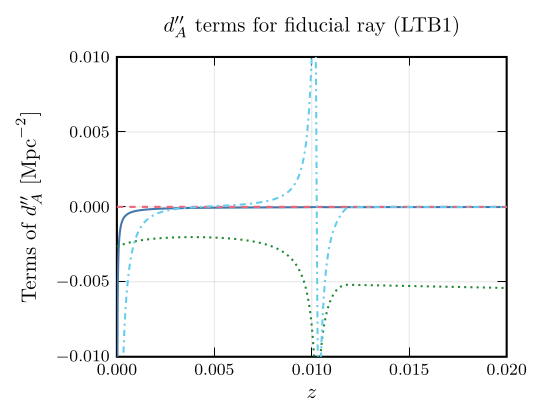

In [129]:
#import Pkg; Pkg.add.(["DifferentialEquations", "Plots", "LaTeXStrings", "PGFPlotsX", "Interpolations", "QuadGK", "ForwardDiff", "NPZ", "Healpix"])
using DifferentialEquations
using Plots
using LaTeXStrings
using PGFPlotsX
using Interpolations
using QuadGK
using ForwardDiff
using NPZ
using Healpix
using Base.Threads
# Plot as .tex (Tikz) files
#pgfplotsx()
#push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")
gr()
default(linewidth=1, framestyle=:box, grid=true, label=nothing, legend=:topright)

#=============================================================================#
# Defining basic constants and cosmological parameters
#=============================================================================#

# Physical constants and parameters
# Fundamental constants
const H_0 = 71.58781594e-3   # Hubble constant [1/Gyr]
const c = 306.5926758        # Speed of light [Mpc/Gyr]
const G_N = 4.498234911e-15  # G in Mpc^3/(M_sun*Gyr^2)

# Cosmological parameters
const Ω_Λ = 0.7
const Ω_m = 0.3

# LTB parameters
const r_b = 40.0
const k_max = 5.4e-8
const n = 4
const m = 4

# Initial conditions
const a_i = 1/1200
const H_i = H_0 * sqrt(Ω_m * a_i^(-3) + Ω_Λ)
const Lambda = 3 * Ω_Λ * H_0^2
const rho_bg = 3 * Ω_m * H_0^2 / (8 * pi * G_N) / a_i^3

# Numerical solution of LTB dynamics
const r_grid = range(1e-6, r_b, length=1_000)
const N = length(r_grid)

# Energy functions for cosmography
const Eo = -c
const Ec = Eo/c^2

# Initial conditions for ray tracing
const xr0 = 20.0# 20 for void, 10 for diov#10.0 #0.1
const xθ0 = pi/2
const xϕ0 = 0

const kt0 = -1/c

const r_σ = 7.0
const δ_0 = 1e-3  # Your new "small" amplitude parameter
const M_bg_coeff = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2
const k_0 = 5/3 * (a_i * H_i / c)^2

# Healpix
Nside = 64
npix  = nside2npix(Nside)

map = HealpixMap{Float64, NestedOrder}(Nside)

theta_hp, phi_hp = pix2ang(map, 1000)
println("Pixel 1000: θ = $theta_hp, φ = $phi_hp")

#=============================================================================#
# Setting up LTB model
#=============================================================================#

# LTB functions
K(r) = ifelse(r > r_b, 0.0, -r^2 * k_max * ((r/r_b)^n - 1)^m)
K_r(r) = ifelse(r > r_b, 0.0, -2*r*k_max*((r/r_b)^n - 1)^m - r*k_max*n*m*((r/r_b)^n-1)^(m-1)*(r/r_b)^n)
K_rr(r) = ifelse(r > r_b, 0.0, -2*k_max*((r/r_b)^n - 1)^m - k_max*n*m*(3+n)*((r/r_b)^n - 1)^(m-1)*(r/r_b)^n - k_max*n^2*m*(m-1)*((r/r_b)^n - 1)^(m-2)*(r/r_b)^(2n))

M(r) = 4/3 * pi * G_N * r^3 * a_i^3 * rho_bg / c^2 * (1 + 3/5 * K(r) * c^2 / (a_i*H_i*r)^2)
M_r(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (3*r^2 + 3/5 * c^2/(a_i*H_i)^2 * (K(r) + r*K_r(r)))
M_rr(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (6*r + 3/5 * c^2/(a_i*H_i)^2 * (2*K_r(r) + r*K_rr(r)))
#=
# DIOV
# The Gaussian density perturbation
δ(r) = δ_0 * exp(-r^2 / (2 * r_σ^2))

# M(r) and its analytical derivatives
M(r)    = M_bg_coeff * r^3 * (1 + δ(r))
M_r(r)  = M_bg_coeff * r^2 * (3 + δ(r) * (3 - (r/r_σ)^2))
M_rr(r) = M_bg_coeff * r * (6 + δ(r) * (6 - 7*(r/r_σ)^2 + (r/r_σ)^4))

# K(r) and its analytical derivatives
K(r)    = k_0 * r^2 * δ(r)
K_r(r)  = k_0 * r * δ(r) * (2 - (r/r_σ)^2)
K_rr(r) = k_0 * δ(r) * (2 - 5*(r/r_σ)^2 + (r/r_σ)^4)
=#
# LCDM background
t_of_a(a) = (2/3) * (1/H_0) / sqrt(Ω_Λ) * asinh(sqrt(Ω_Λ/Ω_m) * a^(3/2))
a(t) = (Ω_m/Ω_Λ)^(1/3) * cbrt(sinh((3/2) * sqrt(Ω_Λ) * H_0 * t))^2
a_t(t) = H_0 * sqrt(Ω_m/a(t) + Ω_Λ * a(t)^2)
H_FLRW(z) = H_0 * sqrt(Ω_m * (1+z)^3 + Ω_Λ)

# Numerical solution of LTB dynamics
t_0 = t_of_a(1.0)
t_i = t_of_a(a_i)
tspan = (t_i, t_0)

# Initial conditions
A_i(r) = a_i * r
A_r_i(r) = a_i
A_rr_i(r) = 0.0
u0 = [A_i.(r_grid); A_r_i.(r_grid); A_rr_i.(r_grid)]

# Parameters for ODEs
p = (
    -K.(r_grid) * c^2,               # p[1]
    2*M.(r_grid) * c^2,           # p[2]
    fill(Lambda/3, length(r_grid)),   # p[3]
    2*M_r.(r_grid) * c^2,         # p[4]
    2*M.(r_grid) * c^2,           # p[5]
    -K_r.(r_grid) * c^2,             # p[6]
    fill(2*Lambda/3, length(r_grid)), # p[7]
    -K_rr.(r_grid) * c^2,            # p[8]
    2*M_rr.(r_grid) * c^2,        # p[9]
    -4*M_r.(r_grid) * c^2,        # p[10]
    4*M.(r_grid) * c^2            # p[11]
)

# Defining the system of ODEs for A, A_r, and A_rr
function LTB_eq!(du, u, p, t)
    N = length(u) ÷ 3
    A   = @view u[1:N]
    Ar  = @view u[N+1:2N]
    Arr = @view u[2N+1:end]
    dA   = @view du[1:N]
    dAr  = @view du[N+1:2N]
    dArr = @view du[2N+1:end]

    @. dA = sqrt(p[1] + p[2]/A + p[3]*A^2)
    @. dAr = (p[4]/A - (p[5]*Ar)/(A^2) + p[6] + p[7]*A*Ar) / (2 * dA)
    @. dArr = ((p[8] + p[9]/A + (p[10]*Ar)/(A^2) + (p[11]*Ar^2)/(A^3) - (p[5]*Arr)/(A^2) + p[7]*Ar^2 + p[7]*A*Arr) - 2*dAr^2) / (2 * dA)
end

    
prob_LTB = ODEProblem(LTB_eq!, u0, tspan, p)
sol_LTB = solve(prob_LTB, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Interpolate solution for A, A_r, A_rr and their time derivatives
# GEMINI INSERT START
# 1. Local cubic curve math
@inline function local_cubic(y1, y2, y3, y4, w)
    return y2 + 0.5 * w * (y3 - y1 + w * (2.0*y1 - 5.0*y2 + 4.0*y3 - y4 + w * (3.0*(y2 - y3) + y4 - y1)))
end

# 2. Dynamic, extrapolation-safe evaluator
function fast_eval(sol, t, r, offset, t_deriv=false)
    # Use your dynamically defined grid
    r_start = first(r_grid)
    r_end = last(r_grid)
    dr = step(r_grid)
    
    # Helper to grab values from the solver cleanly
    get_val(idx) = t_deriv ? sol(t, Val{1}, idxs=idx+offset) : sol(t, idxs=idx+offset)

    # Find exact position on the grid
    fi = (r - r_start) / dr + 1
    i = clamp(floor(Int, fi), 1, N-1)
    w = fi - i 
    
    # Extract 4 points. If we are right against the edge (i=1 or i=N-1), 
    # we create a "ghost point" to keep the curve perfectly smooth.
    y2 = get_val(i)
    y3 = get_val(i+1)
    y1 = i > 1 ? get_val(i-1) : 2.0*y2 - y3
    y4 = i < N-1 ? get_val(i+2) : 2.0*y3 - y2
    
    return local_cubic(y1, y2, y3, y4, w)
end

A_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0)
A_r_intp = (t,r) -> fast_eval(sol_LTB, t, r, N)
A_rr_intp = (t,r) -> fast_eval(sol_LTB, t, r, 2*N)
A_t_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0, true)
A_tr_intp = (t,r) -> fast_eval(sol_LTB, t, r, N, true)

# GEMINI INSERT END

# Direct definitions - No middle step needed
A(t, r)   = (r > r_b) ? a(t)*r   : A_intp(t, r)
A_r(t, r)  = (r > r_b) ? a(t)     : A_r_intp(t, r)
A_rr(t, r) = (r > r_b) ? 0.0      : A_rr_intp(t, r)
A_t(t, r)  = (r > r_b) ? a_t(t)*r : A_t_intp(t, r)
A_tr(t, r) = (r > r_b) ? a_t(t)   : A_tr_intp(t, r)

# LTB metric
gtt() = -c^2
grr(t, r) = A_r(t, r)^2 / (1 - K(r))
gθθ(t, r) = A(t, r)^2
gϕϕ(t, r, θ) = A(t, r)^2 * sin(θ)^2

# Calculate rho, theta and sigma of LTB
ρ(t, r) = @. (c^2 / (4*pi*G_N)) * (M_r(r) / (A(t,r)^2 * A_r(t,r)))
θ(t, r) = @. (A_tr(t,r)/A_r(t,r) + 2*A_t(t,r)/A(t,r))
σ²(t, r) = @. (1/3) * (A_tr(t,r)/A_r(t,r) - A_t(t,r)/A(t,r))^2
R(t,r, kt) = (8*pi*G_N/c^4) * ρ(t,r) * kt^2 * c^4 # R = R_\mu\nu k^\mu k^\nu


#=============================================================================#
# Ray tracing
#=============================================================================#

# Geodesic ray tracing
function geodesic_eq!(du, u, p, λ)
    @views x = u[1:4]   # Position: [t, r, θ, φ]
    @views k = u[5:8]   # Momentum: [k_t, k_r, k_θ, k_φ]
    @views D = u[9:12]  # Deviation vector
    @views D_λ = u[13:16] # Deviation velocity
    
    #if x[2] < 0.001 && k[2] < 0
    #    println("Warning: Light ray is at r=0 with negative radial momentum. Reflecting to avoid numerical issues.")
    #    k[2] = -k[2] # Reflect at r=0 to avoid numerical issues
    #end

    A_i = A(x[1], x[2])
    A_r_i = A_r(x[1], x[2])
    A_rr_i = A_rr(x[1], x[2])
    A_t_i = A_t(x[1], x[2])
    A_tr_i = A_tr(x[1], x[2])

    # Geodesic equation: dx/dλ = k
    du[1:4] .= k

    # dk/dλ = -Γ^μ_{αβ} k^α k^β
    du[5] = -(A_tr_i*A_r_i)/(c^2*(1-K(x[2]))) * k[2]^2 - (A_i*A_t_i)/c^2 * k[3]^2 - (A_i*A_t_i*sin(x[3])^2)/c^2 * k[4]^2
    du[6] = -2*(A_tr_i/A_r_i) * k[1]*k[2] - (A_rr_i/A_r_i + K_r(x[2])/(2-2*K(x[2]))) * k[2]^2 + (A_i/A_r_i)*(1-K(x[2])) * k[3]^2 + (A_i/A_r_i)*(1-K(x[2]))*sin(x[3])^2 * k[4]^2
    du[7] = -2*(A_t_i/A_i) * k[1]*k[3] - 2*(A_r_i/A_i) * k[2]*k[3] + cos(x[3])*sin(x[3]) * k[4]^2
    du[8] = -2*(A_t_i/A_i) * k[1]*k[4] - 2*(A_r_i/A_i) * k[2]*k[4] - 2*(cos(x[3])/sin(x[3])) * k[3]*k[4]

    du[9:12] .= D_λ
    du[13:16] .= -R(x[1], x[2], k[1])/2 .* D
end

# Initial conditions of light ray
x0 = [t_0, xr0, xθ0, xϕ0]

p_hat_r = sin(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) + cos(xθ0) * cos(theta_hp)
p_hat_θ = cos(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) - sin(xθ0) * cos(theta_hp)
p_hat_ϕ = sin(theta_hp) * sin(phi_hp - xϕ0)

energy_factor = kt0 * sqrt(-gtt())

kr0 = kt0 * p_hat_r * sqrt(-gtt() / grr(x0[1], x0[2]))
kθ0 = kt0 * p_hat_θ * sqrt(-gtt() / gθθ(x0[1], x0[2]))
kϕ0 = kt0 * p_hat_ϕ * sqrt(-gtt() / gϕϕ(x0[1], x0[2], x0[3]))

k0 = [kt0, kr0, kθ0, kϕ0]

k0[abs.(k0) .< 1e-15] .= 0.0 # Avoid tiny nonzero values that can cause numerical issues

D0 = [0.0, 0.0, 0.0, 0.0] # Flattening matrix D_0
D_λ0 = [1.0, 0.0, 0.0, 1.0] # Flattening matrix V_0

u0 = vcat(x0, k0, D0, D_λ0)

# Raytracing from lambda=0 to lambda=100
lspan = (0, 100)

# Tighter threshold so near-miss rays curve naturally without triggering
condition_r0(u, λ, integrator) = u[2] - 1e-15

function affect_r0!(integrator)
    # Coordinate teleportation
    integrator.u[3] = π - integrator.u[3]   # θ → π - θ
    integrator.u[4] = integrator.u[4] + π   # φ → φ + π
    
    # Momentum adjustment (Preserving the straight-line velocity)
    integrator.u[6] = -integrator.u[6]      # k_r → -k_r  (now moving outward)
    # k_θ remains unchanged! Do NOT flip u[7]
    integrator.u[8] = -integrator.u[8]      # k_φ → -k_φ
end

# Correct argument order: affect_r0! for inward falling (+ to -), nothing for outward (- to +)
cb_r0 = ContinuousCallback(condition_r0, nothing, affect_r0!)

prob_geo = ODEProblem(geodesic_eq!, u0, lspan, callback=cb_r0)
sol_geo = solve(prob_geo, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Collecting solutions
xt(λ) = sol_geo(λ)[1]
xr(λ) = sol_geo(λ)[2]
xθ(λ) = sol_geo(λ)[3]
xϕ(λ) = sol_geo(λ)[4]

kt(λ) = sol_geo(λ)[5]
kr(λ) = sol_geo(λ)[6]
kθ(λ) = sol_geo(λ)[7]
kϕ(λ) = sol_geo(λ)[8]

D(λ) = reshape(sol_geo(λ)[9:12], 2, 2)
D_λ(λ) = reshape(sol_geo(λ)[13:16], 2, 2)

#=============================================================================#
# Cosmography calculations
#=============================================================================#

z(λ) = kt(λ) / kt(0) - 1

dA(λ) = sqrt(D(λ)[1, 1]*D(λ)[2, 2] - D(λ)[1, 2]*D(λ)[2, 1])

r_comoving_FLRW(z) = first(quadgk(z_ -> 1/H_FLRW(z_), 0, z))
dA_FLRW(λ) = r_comoving_FLRW(z(λ)) * c

S(λ) = D_λ(λ) * inv(D(λ))

θ̂(λ) = (S(λ)[1, 1] .+ S(λ)[2, 2])

σ̂²(λ) = (S(λ)[1, 1]^2 + S(λ)[2, 2]^2 + S(λ)[1, 2]^2 + S(λ)[2, 1]^2 - 2 * S(λ)[1, 1] * S(λ)[2, 2] + 2 * S(λ)[1, 2] * S(λ)[2, 1])/4


σrr(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* 2/3*grr(t,r)
σθθ(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gθθ(t,r))
σϕϕ(t,r,θ) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gϕϕ(t,r,θ))


σ_proj(λ) = ((kr(λ) / (c * kt(λ)))^2 * σrr(xt(λ), xr(λ)) 
    + (kθ(λ) / (c * kt(λ)))^2 * σθθ(xt(λ), xr(λ))
    + (kϕ(λ) / (c * kt(λ)))^2 * σϕϕ(xt(λ), xr(λ), xθ(λ)))

H(λ) = θ(xt(λ), xr(λ))/3 + σ_proj(λ)

#=============================================================================#
# Derivatives of angular diameter distance
#=============================================================================#

dA_z(λ) = -θ̂(λ)/(2*(1 + z(λ))^2*Ec*H(λ))*dA(λ)

Rkk(λ) = R(xt(λ), xr(λ), kt(λ))

H_λ(λ) = ForwardDiff.derivative(H, λ)
H_λλ(λ) = ForwardDiff.derivative(H_λ, λ)
Rkk_λ(λ) = ForwardDiff.derivative(Rkk, λ)


dA_zz(λ) = (dA(λ) / (2*(1+z(λ))^4 * Ec^2 * H(λ)^2)) * (
    2*θ̂(λ)*Ec*H(λ)*(1+z(λ)) - 2*σ̂²(λ) - Rkk(λ) - (θ̂(λ)/H(λ))*H_λ(λ)
)

dA_zzz(λ) = (dA(λ) / (2*(1+z(λ))^6 * Ec^3 * H(λ)^3)) * (
    θ̂(λ)*Rkk(λ)/2 
    - 2*0 # Setting Weyl term to zero
    - 3*θ̂(λ)*σ̂²(λ) 
    + 12*Ec*H(λ)*σ̂²(λ)*(1+z(λ))
    + 6*Ec*H(λ)*Rkk(λ)*(1+z(λ))
    + 6*Ec*θ̂(λ)*(1+z(λ))*H_λ(λ)
    - 6*Ec^2*H(λ)^2*θ̂(λ)*(1+z(λ))^2
    - 6*σ̂²(λ)/H(λ)*H_λ(λ)
    - 3*Rkk(λ)/H(λ)*H_λ(λ)
    - 3*θ̂(λ)/H(λ)^2*H_λ(λ)^2
    + θ̂(λ)/H(λ)*H_λλ(λ)
    + Rkk_λ(λ)
)


z_vals = z.(sol_geo.t)
λ_of_z = linear_interpolation(z_vals, sol_geo.t, extrapolation_bc=Line())

function dA_exp(z_0)
    λ_0 = λ_of_z(z_0)
    c0_z0 = dA(λ_0)
    c1_z0 = dA_z(λ_0)
    c2_z0 = 0.5 * dA_zz(λ_0)
    c3_z0 = (1/6) * dA_zzz(λ_0)

    dA_z0(z_val) = c0_z0 + c1_z0*(z_val - z_0) + c2_z0*(z_val - z_0)^2 + c3_z0*(z_val - z_0)^3
    return dA_z0
end

#=============================================================================#
# Plotting
#=============================================================================#
λ_ = sol_geo.t[sol_geo.t .> 0.01]
z_eval = z.(λ_)

Plots.default(
    fontfamily = "Computer Modern",
    titlefont  = font(10, "Computer Modern"), # Forces title to match Makie titlesize
    guidefont  = font(10, "Computer Modern"), # Matches Makie labelsize
    tickfont   = font(8, "Computer Modern"), # Matches Makie ticklabelsize
    legendfont = font(8, "Computer Modern"), 
    size       = (330, 270),  
    linewidth  = 1,         
    legend     = :topleft     
)

pgfplotsx() 

push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")

using PlotUtils
tol_colors = PlotUtils.palette(:tol_bright)
line_colors = repeat(
    [
        tol_colors[1],
        tol_colors[2],
        tol_colors[3],
        tol_colors[5],
        tol_colors[4]
    ],
    outer = 1
)

#dA_zz(λ) =(2*θ̂(λ)*Ec*H(λ)*(1+z(λ)) - 2*σ̂²(λ) - Rkk(λ) - (θ̂(λ)/H(λ))*H_λ(λ))
dazz1 = plot(
    z_eval, 
    2 .* θ̂.(λ_) .* Ec .* H.(λ_) .* (1 .+ z_eval), 
    label=L"T_1", linestyle=:solid,
    color=line_colors[1], legend=:none
)

plot!(
    dazz1,
    z_eval, 
    -2 .* σ̂².(λ_)*1e15, 
    label=L"10^{15}T_2", linestyle=:dash,
    color=line_colors[2]
)

plot!(
    dazz1,
    z_eval, 
    -Rkk.(λ_)*1e5, 
    label=L"10^{5}T_3", linestyle=:dot,
    color=line_colors[3]
)

plot!(
    dazz1,
    z_eval, 
    -(θ̂.(λ_) ./ H.(λ_)) .* H_λ.(λ_), 
    label=L"T_4", linestyle=:dashdot,
    color=line_colors[4]
)
xlabel!(L"z")
ylabel!(L"\text{Terms of } d_A'' \text{ [Mpc}^{-2}\text{]}")
ylims!(-0.01, 0.01)
xlims!(0, 0.02)
title!(L"d_A'' \text{ terms for fiducial ray (LTB1)}")
# Display the plot
#display(dazz1)

Pixel 1000: θ = 0.9350850413935945, φ = 0.7608544707912779


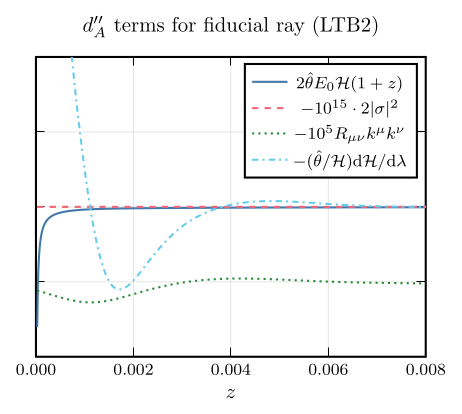

In [134]:
#import Pkg; Pkg.add.(["DifferentialEquations", "Plots", "LaTeXStrings", "PGFPlotsX", "Interpolations", "QuadGK", "ForwardDiff", "NPZ", "Healpix"])
using DifferentialEquations
using Plots
using LaTeXStrings
using PGFPlotsX
using Interpolations
using QuadGK
using ForwardDiff
using NPZ
using Healpix
using Base.Threads
# Plot as .tex (Tikz) files
#pgfplotsx()
#push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")
gr()
default(linewidth=1, framestyle=:box, grid=true, label=nothing, legend=:topright)

#=============================================================================#
# Defining basic constants and cosmological parameters
#=============================================================================#

# Physical constants and parameters
# Fundamental constants
const H_0 = 71.58781594e-3   # Hubble constant [1/Gyr]
const c = 306.5926758        # Speed of light [Mpc/Gyr]
const G_N = 4.498234911e-15  # G in Mpc^3/(M_sun*Gyr^2)

# Cosmological parameters
const Ω_Λ = 0.7
const Ω_m = 0.3

# LTB parameters
const r_b = 40.0
const k_max = 5.4e-8
const n = 4
const m = 4

# Initial conditions
const a_i = 1/1200
const H_i = H_0 * sqrt(Ω_m * a_i^(-3) + Ω_Λ)
const Lambda = 3 * Ω_Λ * H_0^2
const rho_bg = 3 * Ω_m * H_0^2 / (8 * pi * G_N) / a_i^3

# Numerical solution of LTB dynamics
const r_grid = range(1e-6, r_b, length=1_000)
const N = length(r_grid)

# Energy functions for cosmography
const Eo = -c
const Ec = Eo/c^2

# Initial conditions for ray tracing
const xr0 = 10.0# 20 for void, 10 for diov#10.0 #0.1
const xθ0 = pi/2
const xϕ0 = 0

const kt0 = -1/c

const r_σ = 7.0
const δ_0 = 1e-3  # Your new "small" amplitude parameter
const M_bg_coeff = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2
const k_0 = 5/3 * (a_i * H_i / c)^2

# Healpix
Nside = 64
npix  = nside2npix(Nside)

map = HealpixMap{Float64, NestedOrder}(Nside)

theta_hp, phi_hp = pix2ang(map, 1000)
println("Pixel 1000: θ = $theta_hp, φ = $phi_hp")

#=============================================================================#
# Setting up LTB model
#=============================================================================#
#=
# LTB functions
K(r) = ifelse(r > r_b, 0.0, -r^2 * k_max * ((r/r_b)^n - 1)^m)
K_r(r) = ifelse(r > r_b, 0.0, -2*r*k_max*((r/r_b)^n - 1)^m - r*k_max*n*m*((r/r_b)^n-1)^(m-1)*(r/r_b)^n)
K_rr(r) = ifelse(r > r_b, 0.0, -2*k_max*((r/r_b)^n - 1)^m - k_max*n*m*(3+n)*((r/r_b)^n - 1)^(m-1)*(r/r_b)^n - k_max*n^2*m*(m-1)*((r/r_b)^n - 1)^(m-2)*(r/r_b)^(2n))

M(r) = 4/3 * pi * G_N * r^3 * a_i^3 * rho_bg / c^2 * (1 + 3/5 * K(r) * c^2 / (a_i*H_i*r)^2)
M_r(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (3*r^2 + 3/5 * c^2/(a_i*H_i)^2 * (K(r) + r*K_r(r)))
M_rr(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (6*r + 3/5 * c^2/(a_i*H_i)^2 * (2*K_r(r) + r*K_rr(r)))
=#
# DIOV
# The Gaussian density perturbation
δ(r) = δ_0 * exp(-r^2 / (2 * r_σ^2))

# M(r) and its analytical derivatives
M(r)    = M_bg_coeff * r^3 * (1 + δ(r))
M_r(r)  = M_bg_coeff * r^2 * (3 + δ(r) * (3 - (r/r_σ)^2))
M_rr(r) = M_bg_coeff * r * (6 + δ(r) * (6 - 7*(r/r_σ)^2 + (r/r_σ)^4))

# K(r) and its analytical derivatives
K(r)    = k_0 * r^2 * δ(r)
K_r(r)  = k_0 * r * δ(r) * (2 - (r/r_σ)^2)
K_rr(r) = k_0 * δ(r) * (2 - 5*(r/r_σ)^2 + (r/r_σ)^4)

# LCDM background
t_of_a(a) = (2/3) * (1/H_0) / sqrt(Ω_Λ) * asinh(sqrt(Ω_Λ/Ω_m) * a^(3/2))
a(t) = (Ω_m/Ω_Λ)^(1/3) * cbrt(sinh((3/2) * sqrt(Ω_Λ) * H_0 * t))^2
a_t(t) = H_0 * sqrt(Ω_m/a(t) + Ω_Λ * a(t)^2)
H_FLRW(z) = H_0 * sqrt(Ω_m * (1+z)^3 + Ω_Λ)

# Numerical solution of LTB dynamics
t_0 = t_of_a(1.0)
t_i = t_of_a(a_i)
tspan = (t_i, t_0)

# Initial conditions
A_i(r) = a_i * r
A_r_i(r) = a_i
A_rr_i(r) = 0.0
u0 = [A_i.(r_grid); A_r_i.(r_grid); A_rr_i.(r_grid)]

# Parameters for ODEs
p = (
    -K.(r_grid) * c^2,               # p[1]
    2*M.(r_grid) * c^2,           # p[2]
    fill(Lambda/3, length(r_grid)),   # p[3]
    2*M_r.(r_grid) * c^2,         # p[4]
    2*M.(r_grid) * c^2,           # p[5]
    -K_r.(r_grid) * c^2,             # p[6]
    fill(2*Lambda/3, length(r_grid)), # p[7]
    -K_rr.(r_grid) * c^2,            # p[8]
    2*M_rr.(r_grid) * c^2,        # p[9]
    -4*M_r.(r_grid) * c^2,        # p[10]
    4*M.(r_grid) * c^2            # p[11]
)

# Defining the system of ODEs for A, A_r, and A_rr
function LTB_eq!(du, u, p, t)
    N = length(u) ÷ 3
    A   = @view u[1:N]
    Ar  = @view u[N+1:2N]
    Arr = @view u[2N+1:end]
    dA   = @view du[1:N]
    dAr  = @view du[N+1:2N]
    dArr = @view du[2N+1:end]

    @. dA = sqrt(p[1] + p[2]/A + p[3]*A^2)
    @. dAr = (p[4]/A - (p[5]*Ar)/(A^2) + p[6] + p[7]*A*Ar) / (2 * dA)
    @. dArr = ((p[8] + p[9]/A + (p[10]*Ar)/(A^2) + (p[11]*Ar^2)/(A^3) - (p[5]*Arr)/(A^2) + p[7]*Ar^2 + p[7]*A*Arr) - 2*dAr^2) / (2 * dA)
end

    
prob_LTB = ODEProblem(LTB_eq!, u0, tspan, p)
sol_LTB = solve(prob_LTB, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Interpolate solution for A, A_r, A_rr and their time derivatives
# GEMINI INSERT START
# 1. Local cubic curve math
@inline function local_cubic(y1, y2, y3, y4, w)
    return y2 + 0.5 * w * (y3 - y1 + w * (2.0*y1 - 5.0*y2 + 4.0*y3 - y4 + w * (3.0*(y2 - y3) + y4 - y1)))
end

# 2. Dynamic, extrapolation-safe evaluator
function fast_eval(sol, t, r, offset, t_deriv=false)
    # Use your dynamically defined grid
    r_start = first(r_grid)
    r_end = last(r_grid)
    dr = step(r_grid)
    
    # Helper to grab values from the solver cleanly
    get_val(idx) = t_deriv ? sol(t, Val{1}, idxs=idx+offset) : sol(t, idxs=idx+offset)

    # Find exact position on the grid
    fi = (r - r_start) / dr + 1
    i = clamp(floor(Int, fi), 1, N-1)
    w = fi - i 
    
    # Extract 4 points. If we are right against the edge (i=1 or i=N-1), 
    # we create a "ghost point" to keep the curve perfectly smooth.
    y2 = get_val(i)
    y3 = get_val(i+1)
    y1 = i > 1 ? get_val(i-1) : 2.0*y2 - y3
    y4 = i < N-1 ? get_val(i+2) : 2.0*y3 - y2
    
    return local_cubic(y1, y2, y3, y4, w)
end

A_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0)
A_r_intp = (t,r) -> fast_eval(sol_LTB, t, r, N)
A_rr_intp = (t,r) -> fast_eval(sol_LTB, t, r, 2*N)
A_t_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0, true)
A_tr_intp = (t,r) -> fast_eval(sol_LTB, t, r, N, true)

# GEMINI INSERT END

# Direct definitions - No middle step needed
A(t, r)   = (r > r_b) ? a(t)*r   : A_intp(t, r)
A_r(t, r)  = (r > r_b) ? a(t)     : A_r_intp(t, r)
A_rr(t, r) = (r > r_b) ? 0.0      : A_rr_intp(t, r)
A_t(t, r)  = (r > r_b) ? a_t(t)*r : A_t_intp(t, r)
A_tr(t, r) = (r > r_b) ? a_t(t)   : A_tr_intp(t, r)

# LTB metric
gtt() = -c^2
grr(t, r) = A_r(t, r)^2 / (1 - K(r))
gθθ(t, r) = A(t, r)^2
gϕϕ(t, r, θ) = A(t, r)^2 * sin(θ)^2

# Calculate rho, theta and sigma of LTB
ρ(t, r) = @. (c^2 / (4*pi*G_N)) * (M_r(r) / (A(t,r)^2 * A_r(t,r)))
θ(t, r) = @. (A_tr(t,r)/A_r(t,r) + 2*A_t(t,r)/A(t,r))
σ²(t, r) = @. (1/3) * (A_tr(t,r)/A_r(t,r) - A_t(t,r)/A(t,r))^2
R(t,r, kt) = (8*pi*G_N/c^4) * ρ(t,r) * kt^2 * c^4 # R = R_\mu\nu k^\mu k^\nu

#=============================================================================#
# Ray tracing
#=============================================================================#

# Geodesic ray tracing
function geodesic_eq!(du, u, p, λ)
    @views x = u[1:4]   # Position: [t, r, θ, φ]
    @views k = u[5:8]   # Momentum: [k_t, k_r, k_θ, k_φ]
    @views D = u[9:12]  # Deviation vector
    @views D_λ = u[13:16] # Deviation velocity
    
    #if x[2] < 0.001 && k[2] < 0
    #    println("Warning: Light ray is at r=0 with negative radial momentum. Reflecting to avoid numerical issues.")
    #    k[2] = -k[2] # Reflect at r=0 to avoid numerical issues
    #end

    A_i = A(x[1], x[2])
    A_r_i = A_r(x[1], x[2])
    A_rr_i = A_rr(x[1], x[2])
    A_t_i = A_t(x[1], x[2])
    A_tr_i = A_tr(x[1], x[2])

    # Geodesic equation: dx/dλ = k
    du[1:4] .= k

    # dk/dλ = -Γ^μ_{αβ} k^α k^β
    du[5] = -(A_tr_i*A_r_i)/(c^2*(1-K(x[2]))) * k[2]^2 - (A_i*A_t_i)/c^2 * k[3]^2 - (A_i*A_t_i*sin(x[3])^2)/c^2 * k[4]^2
    du[6] = -2*(A_tr_i/A_r_i) * k[1]*k[2] - (A_rr_i/A_r_i + K_r(x[2])/(2-2*K(x[2]))) * k[2]^2 + (A_i/A_r_i)*(1-K(x[2])) * k[3]^2 + (A_i/A_r_i)*(1-K(x[2]))*sin(x[3])^2 * k[4]^2
    du[7] = -2*(A_t_i/A_i) * k[1]*k[3] - 2*(A_r_i/A_i) * k[2]*k[3] + cos(x[3])*sin(x[3]) * k[4]^2
    du[8] = -2*(A_t_i/A_i) * k[1]*k[4] - 2*(A_r_i/A_i) * k[2]*k[4] - 2*(cos(x[3])/sin(x[3])) * k[3]*k[4]

    du[9:12] .= D_λ
    du[13:16] .= -R(x[1], x[2], k[1])/2 .* D
end

# Initial conditions of light ray
x0 = [t_0, xr0, xθ0, xϕ0]

p_hat_r = sin(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) + cos(xθ0) * cos(theta_hp)
p_hat_θ = cos(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) - sin(xθ0) * cos(theta_hp)
p_hat_ϕ = sin(theta_hp) * sin(phi_hp - xϕ0)

energy_factor = kt0 * sqrt(-gtt())

kr0 = kt0 * p_hat_r * sqrt(-gtt() / grr(x0[1], x0[2]))
kθ0 = kt0 * p_hat_θ * sqrt(-gtt() / gθθ(x0[1], x0[2]))
kϕ0 = kt0 * p_hat_ϕ * sqrt(-gtt() / gϕϕ(x0[1], x0[2], x0[3]))

k0 = [kt0, kr0, kθ0, kϕ0]

k0[abs.(k0) .< 1e-15] .= 0.0 # Avoid tiny nonzero values that can cause numerical issues

D0 = [0.0, 0.0, 0.0, 0.0] # Flattening matrix D_0
D_λ0 = [1.0, 0.0, 0.0, 1.0] # Flattening matrix V_0

u0 = vcat(x0, k0, D0, D_λ0)

# Raytracing from lambda=0 to lambda=100
lspan = (0, 100)

# Tighter threshold so near-miss rays curve naturally without triggering
condition_r0(u, λ, integrator) = u[2] - 1e-15

function affect_r0!(integrator)
    # Coordinate teleportation
    integrator.u[3] = π - integrator.u[3]   # θ → π - θ
    integrator.u[4] = integrator.u[4] + π   # φ → φ + π
    
    # Momentum adjustment (Preserving the straight-line velocity)
    integrator.u[6] = -integrator.u[6]      # k_r → -k_r  (now moving outward)
    # k_θ remains unchanged! Do NOT flip u[7]
    integrator.u[8] = -integrator.u[8]      # k_φ → -k_φ
end

# Correct argument order: affect_r0! for inward falling (+ to -), nothing for outward (- to +)
cb_r0 = ContinuousCallback(condition_r0, nothing, affect_r0!)

prob_geo = ODEProblem(geodesic_eq!, u0, lspan, callback=cb_r0)
sol_geo = solve(prob_geo, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Collecting solutions
xt(λ) = sol_geo(λ)[1]
xr(λ) = sol_geo(λ)[2]
xθ(λ) = sol_geo(λ)[3]
xϕ(λ) = sol_geo(λ)[4]

kt(λ) = sol_geo(λ)[5]
kr(λ) = sol_geo(λ)[6]
kθ(λ) = sol_geo(λ)[7]
kϕ(λ) = sol_geo(λ)[8]

D(λ) = reshape(sol_geo(λ)[9:12], 2, 2)
D_λ(λ) = reshape(sol_geo(λ)[13:16], 2, 2)

#=============================================================================#
# Cosmography calculations
#=============================================================================#

z(λ) = kt(λ) / kt(0) - 1

dA(λ) = sqrt(D(λ)[1, 1]*D(λ)[2, 2] - D(λ)[1, 2]*D(λ)[2, 1])

r_comoving_FLRW(z) = first(quadgk(z_ -> 1/H_FLRW(z_), 0, z))
dA_FLRW(λ) = r_comoving_FLRW(z(λ)) * c

S(λ) = D_λ(λ) * inv(D(λ))

θ̂(λ) = (S(λ)[1, 1] .+ S(λ)[2, 2])

σ̂²(λ) = (S(λ)[1, 1]^2 + S(λ)[2, 2]^2 + S(λ)[1, 2]^2 + S(λ)[2, 1]^2 - 2 * S(λ)[1, 1] * S(λ)[2, 2] + 2 * S(λ)[1, 2] * S(λ)[2, 1])/4


σrr(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* 2/3*grr(t,r)
σθθ(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gθθ(t,r))
σϕϕ(t,r,θ) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gϕϕ(t,r,θ))


σ_proj(λ) = ((kr(λ) / (c * kt(λ)))^2 * σrr(xt(λ), xr(λ)) 
    + (kθ(λ) / (c * kt(λ)))^2 * σθθ(xt(λ), xr(λ))
    + (kϕ(λ) / (c * kt(λ)))^2 * σϕϕ(xt(λ), xr(λ), xθ(λ)))

H(λ) = θ(xt(λ), xr(λ))/3 + σ_proj(λ)

#=============================================================================#
# Derivatives of angular diameter distance
#=============================================================================#

dA_z(λ) = -θ̂(λ)/(2*(1 + z(λ))^2*Ec*H(λ))*dA(λ)

Rkk(λ) = R(xt(λ), xr(λ), kt(λ))

H_λ(λ) = ForwardDiff.derivative(H, λ)
H_λλ(λ) = ForwardDiff.derivative(H_λ, λ)
Rkk_λ(λ) = ForwardDiff.derivative(Rkk, λ)


dA_zz(λ) = (dA(λ) / (2*(1+z(λ))^4 * Ec^2 * H(λ)^2)) * (
    2*θ̂(λ)*Ec*H(λ)*(1+z(λ)) - 2*σ̂²(λ) - Rkk(λ) - (θ̂(λ)/H(λ))*H_λ(λ)
)

dA_zzz(λ) = (dA(λ) / (2*(1+z(λ))^6 * Ec^3 * H(λ)^3)) * (
    θ̂(λ)*Rkk(λ)/2 
    - 2*0 # Setting Weyl term to zero
    - 3*θ̂(λ)*σ̂²(λ) 
    + 12*Ec*H(λ)*σ̂²(λ)*(1+z(λ))
    + 6*Ec*H(λ)*Rkk(λ)*(1+z(λ))
    + 6*Ec*θ̂(λ)*(1+z(λ))*H_λ(λ)
    - 6*Ec^2*H(λ)^2*θ̂(λ)*(1+z(λ))^2
    - 6*σ̂²(λ)/H(λ)*H_λ(λ)
    - 3*Rkk(λ)/H(λ)*H_λ(λ)
    - 3*θ̂(λ)/H(λ)^2*H_λ(λ)^2
    + θ̂(λ)/H(λ)*H_λλ(λ)
    + Rkk_λ(λ)
)


z_vals = z.(sol_geo.t)
λ_of_z = linear_interpolation(z_vals, sol_geo.t, extrapolation_bc=Line())

function dA_exp(z_0)
    λ_0 = λ_of_z(z_0)
    c0_z0 = dA(λ_0)
    c1_z0 = dA_z(λ_0)
    c2_z0 = 0.5 * dA_zz(λ_0)
    c3_z0 = (1/6) * dA_zzz(λ_0)

    dA_z0(z_val) = c0_z0 + c1_z0*(z_val - z_0) + c2_z0*(z_val - z_0)^2 + c3_z0*(z_val - z_0)^3
    return dA_z0
end

#=============================================================================#
# Plotting
#=============================================================================#


λ_ = sol_geo.t[sol_geo.t .> 0.1]
z_eval = z.(λ_)

Plots.default(
    fontfamily = "Computer Modern",
    titlefont  = font(10, "Computer Modern"), # Forces title to match Makie titlesize
    guidefont  = font(10, "Computer Modern"), # Matches Makie labelsize
    tickfont   = font(8, "Computer Modern"), # Matches Makie ticklabelsize
    legendfont = font(8, "Computer Modern"), 
    size       = (330, 270),  
    linewidth  = 1,         
    legend     = :topleft     
)

pgfplotsx() 

push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")

using PlotUtils
tol_colors = PlotUtils.palette(:tol_bright)
line_colors = repeat(
    [
        tol_colors[1],
        tol_colors[2],
        tol_colors[3],
        tol_colors[5],
        tol_colors[4]
    ],
    outer = 1
)

#dA_zz(λ) =(2*θ̂(λ)*Ec*H(λ)*(1+z(λ)) - 2*σ̂²(λ) - Rkk(λ) - (θ̂(λ)/H(λ))*H_λ(λ))
dazz2 = plot(
    z_eval, 
    2 .* θ̂.(λ_) .* Ec .* H.(λ_) .* (1 .+ z_eval), 
    label=L"2\hat{\theta}E_0\mathcal{H}(1+z)", linestyle=:solid,
    color=line_colors[1], legend=:topright,
    yformatter = _ -> "",   # <--- THIS HIDES THE Y-AXIS NUMBERS
    ylabel = "",            # <--- THIS HIDES ANY Y-AXIS LABEL
)

plot!(
    dazz2,
    z_eval, 
    -2 .* σ̂².(λ_)*1e15, 
    label=L"- 10^{15}\cdot2|\sigma|^2", linestyle=:dash,
    color=line_colors[2]
)

plot!(
    dazz2,
    z_eval, 
    -Rkk.(λ_)*1e5, 
    label=L"-10^{5}R_{\mu\nu}k^\mu k^\nu", linestyle=:dot,
    color=line_colors[3]
)

plot!(
    dazz2,
    z_eval, 
    -(θ̂.(λ_) ./ H.(λ_)) .* H_λ.(λ_), 
    label=L"-(\hat{\theta}/\mathcal{H})\mathrm{d}\mathcal{H}/\mathrm{d}\lambda", linestyle=:dashdot,
    color=line_colors[4]
)

ylims!(-0.01, 0.01)
xlims!(0, 0.008)
xlabel!(L"z")
title!(L"d_A''\text{ terms for fiducial ray (LTB2)}")
# Display the plot
#display(dazz2)


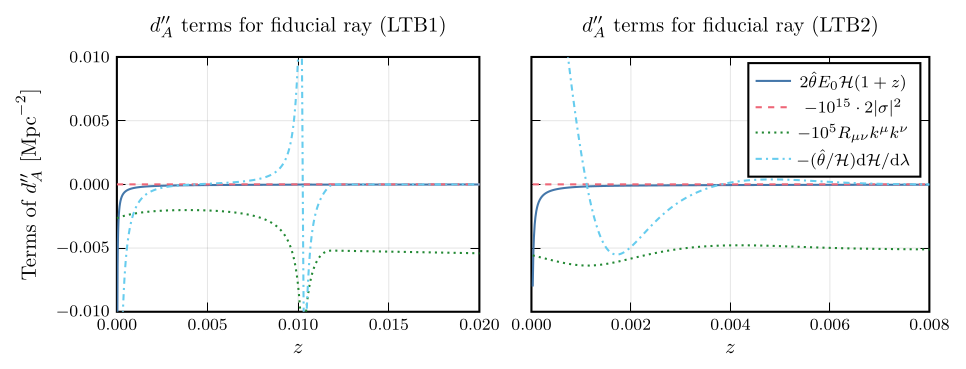

In [ ]:
combined = plot(
    dazz1, dazz2, 
    layout = (1, 2),     # 1 row, 2 columns
    link = :y,           # Links the y-axes
    size = (600, 240),   # Double the width to fit both nicely
    framestyle = :box,
    left_margin = [-2Plots.mm -8Plots.mm],
    fontfamily = "Computer Modern",
    extra_kwargs = Dict(:subplot => Dict(
    "width" => "0.95\\textwidth", 
    "height" => "67mm"))
)
savefig(combined, "dA_zz_terms.tex")
savefig(combined, "dA_zz_terms.pdf")

display(combined)